# Rat consolidation network

The network learns a new association through repeated replay alongside older experiences. We measure how much of the new association the cortical network can retrieve after 1, 7, 14, and 28 days.

This reconstructs the mechanism in McClelland et al. (1995), pp. 441–442, Figure 12b. The parameters added for this implementation are listed in `RAT_NOTES.md`.

## Setup

In [1]:
# Locate shared data when opened from this notebook folder or the project root.
from pathlib import Path
import os, sys
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / 'data' / 'targets.csv').is_file()), Path.cwd())
os.chdir(project_root)
sys.path.insert(0, str(project_root / 'notebooks' / 'semantic'))

import numpy as np
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt

torch.set_num_threads(1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Associations

Twenty random input–output pairs represent background experiences. A twenty-first pair represents the environment–tone–shock (ETS) association. Each input has 16 binary values; output targets are 0.05 or 0.95.

In [2]:
def make_data(seed=0):
    rng = np.random.default_rng(seed)
    inputs = rng.integers(0, 2, (21, 16))
    targets = .05 + .9 * rng.integers(0, 2, (21, 16))
    return torch.tensor(inputs, dtype=torch.float64), torch.tensor(targets, dtype=torch.float64)

inputs, targets = make_data(seed=0)
pd.DataFrame({"ETS input": inputs[-1].numpy(), "ETS target": targets[-1].numpy()}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
ETS input,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,1.00,0.00,1.00,1.00
ETS target,0.05,0.05,0.95,0.05,0.95,0.95,0.05,0.05,0.05,0.95,0.95,0.05,0.95,0.05,0.95,0.95


## 2. Network and training

The cortical network has 16 input, 16 hidden, and 16 output units. It first learns the background pairs. Each subsequent day presents all 20 background pairs and the ETS pair once, in shuffled order. The hippocampus supplies ETS replay; its trace strength is held constant.

Training uses sigmoid activations, half the summed squared error, and SGD without momentum.

In [3]:
class RatNetwork(nn.Sequential):
    def __init__(self, seed=0):
        with torch.random.fork_rng():
            torch.manual_seed(seed)
            super().__init__(nn.Linear(16, 16), nn.Sigmoid(),
                             nn.Linear(16, 16), nn.Sigmoid())
            self.double()
            for parameter in self.parameters():
                nn.init.uniform_(parameter, -.5, .5)

def train_epoch(model, optimizer, inputs, targets, order):
    for i in order:
        optimizer.zero_grad()
        loss = .5 * (model(inputs[i]) - targets[i]).square().sum()
        loss.backward()
        optimizer.step()

In [4]:
def run(seed=0, learning_rate=.3, pretraining_epochs=100, days=28, lesion_day=None):
    """One epoch/day. Optional lesion stops ETS replay after that day's training.

    Default records cortical performance at each delay, as in Figure 12b.
    lesion_day is an additional intervention for testing the replay mechanism.
    """
    if days < 0 or pretraining_epochs < 0 or learning_rate < 0:
        raise ValueError('Training parameters must be non-negative.')
    if lesion_day is not None and not 0 <= lesion_day <= days:
        raise ValueError('lesion_day must be between 0 and days.')
    inputs, targets = make_data(seed)
    model = RatNetwork(seed)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    order_rng = np.random.default_rng(seed + 10000)
    for _ in range(pretraining_epochs):
        train_epoch(model, optimizer, inputs, targets, order_rng.permutation(20))
    records = []
    for day in range(days + 1):
        if day:
            order = order_rng.permutation(21)
            if lesion_day is not None and day > lesion_day:
                order = order[order != 20]
            train_epoch(model, optimizer, inputs, targets, order)
        with torch.no_grad():
            output = model(inputs)
            records.append(dict(day=day, output=output[-1].tolist(),
                                hidden=torch.sigmoid(model[0](inputs[-1])).tolist(),
                                mse=(output[-1] - targets[-1]).square().mean().item(),
                                background_mse=(output[:20] - targets[:20]).square().mean().item()))
    for frame in records:
        frame['score'] = 1 - frame['mse'] / records[0]['mse']
    return dict(seed=seed, learning_rate=learning_rate, pretraining_epochs=pretraining_epochs,
                lesion_day=lesion_day, inputs=inputs.tolist(), targets=targets.tolist(), frames=records)

In [5]:
result = run(seed=0, learning_rate=0.3, pretraining_epochs=100, days=28)
history = pd.DataFrame(result['frames'])
history.loc[history.day.isin([0, 1, 7, 14, 28]), ['day', 'mse', 'background_mse', 'score']]

,day,mse,background_mse,score
0,0,0.265747,0.028763,0.000000
1,1,0.233639,0.028560,0.120820
7,7,0.141705,0.026371,0.466766
14,14,0.109938,0.023685,0.586307
28,28,0.086681,0.018726,0.673820


## 3. Consolidation

The score is $1-\mathrm{MSE}_{day}/\mathrm{MSE}_{0}$: the fraction of the initial ETS prediction error removed by learning. The curve measures cortical retrieval at each delay.

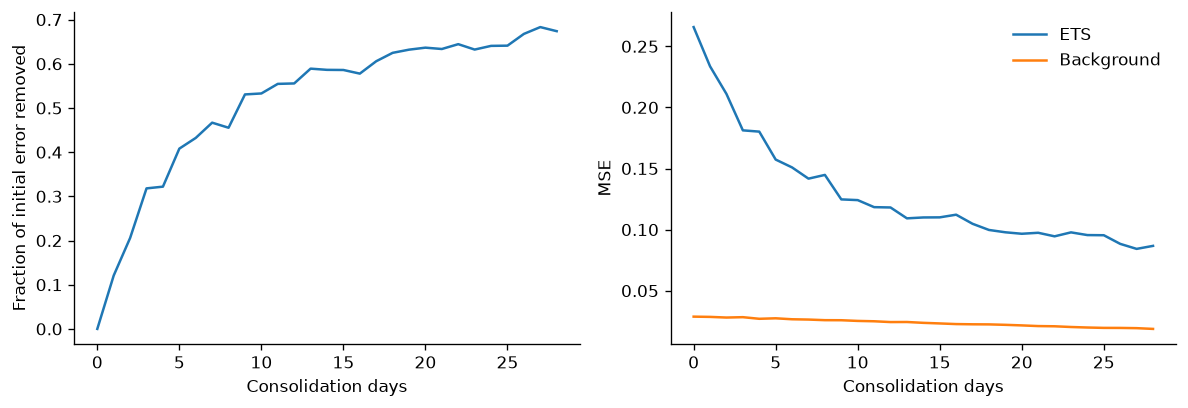

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history.day, history.score)
axes[0].set(xlabel='Consolidation days', ylabel='Fraction of initial error removed')
axes[1].plot(history.day, history.mse, label='ETS')
axes[1].plot(history.day, history.background_mse, label='Background')
axes[1].set(xlabel='Consolidation days', ylabel='MSE')
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

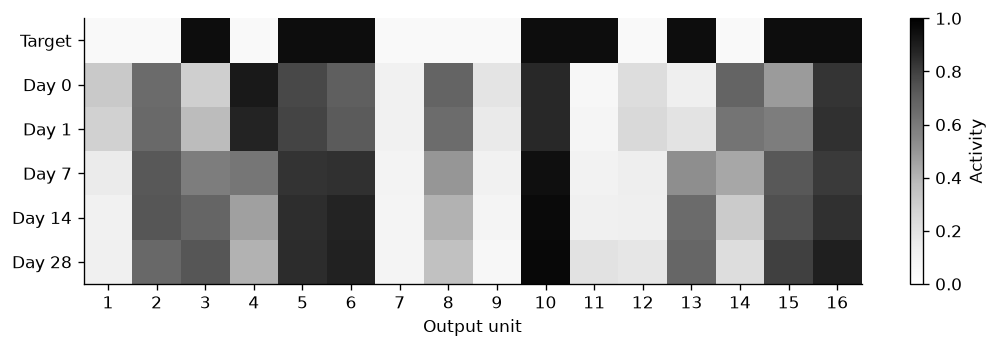

In [7]:
values = np.array([result['targets'][-1]] + [result['frames'][day]['output'] for day in [0, 1, 7, 14, 28]])
fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(values, vmin=0, vmax=1, cmap='Greys', aspect='auto')
ax.set(yticks=range(6), yticklabels=['Target', 'Day 0', 'Day 1', 'Day 7', 'Day 14', 'Day 28'],
       xticks=range(16), xticklabels=range(1, 17), xlabel='Output unit')
fig.colorbar(im, ax=ax, label='Activity')
fig.tight_layout()
plt.show()

## 4. Repeated runs

The line is the mean across 10 random seeds; the shaded band spans their minimum and maximum scores.

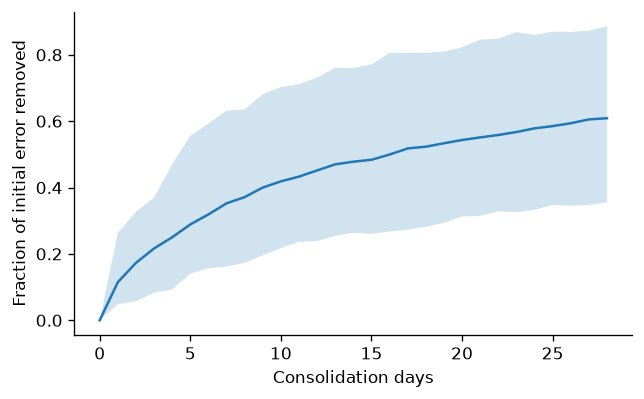

,mean,low,high
1,0.114771,0.048123,0.263560
7,0.352401,0.162002,0.631914
14,0.477899,0.263710,0.760401
28,0.608800,0.355619,0.885927


In [8]:
def ensemble(seeds=range(10), **kwargs):
    runs = [run(seed=seed, **kwargs) for seed in seeds]
    scores = np.array([[f['score'] for f in result['frames']] for result in runs])
    return runs, dict(mean=scores.mean(0).tolist(), low=scores.min(0).tolist(), high=scores.max(0).tolist())

runs, summary = ensemble(range(10))
days = np.arange(29)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(days, summary['mean'])
ax.fill_between(days, summary['low'], summary['high'], alpha=.2)
ax.set(xlabel='Consolidation days', ylabel='Fraction of initial error removed')
plt.show()
pd.DataFrame(summary, index=days).loc[[1, 7, 14, 28]]

## 5. Stopping replay

As an additional intervention, stop ETS replay after day 7 while continuing background training. This tests the effect of losing the replay source.

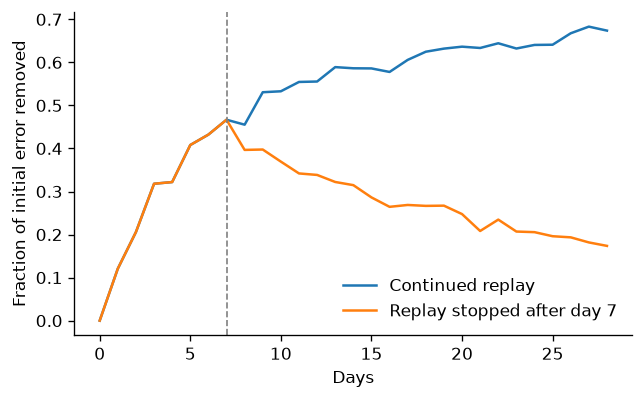

In [9]:
lesioned = run(seed=0, lesion_day=7)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history.day, history.score, label='Continued replay')
ax.plot(history.day, [f['score'] for f in lesioned['frames']], label='Replay stopped after day 7')
ax.axvline(7, color='gray', linestyle='--', linewidth=1)
ax.set(xlabel='Days', ylabel='Fraction of initial error removed')
ax.legend(frameon=False)
plt.show()

## Save results

In [10]:
import json
from pathlib import Path

destination = Path('outputs/rat')
destination.mkdir(parents=True, exist_ok=True)
history[['day', 'mse', 'background_mse', 'score']].to_csv(destination / 'seed0.csv', index=False)
(destination / 'runs.json').write_text(json.dumps({'runs': runs, 'summary': summary}), encoding='utf-8')

292062